IS 362 – Project 2

Name: Rezoan Hossain

Goal:
In this project I will use 3 “wide/untidy” datasets from the Week 5 Discussion.
For each dataset I will (1) save a wide CSV, (2) tidy/transform it using pandas, and (3) do a simple analysis + chart.

Datasets used:

1. Climate of New York City (Wikipedia)

2. List of best-selling video games (Wikipedia)

3. NASA JPL Planets table

Setup / Libraries
In this notebook I will use:

pandas for reading tables/CSV and tidying data (reshape, clean columns).

numpy for numeric help (missing values, calculations).

matplotlib for simple charts.

I also set display options so I can see all columns when I print wide tables.

In [1]:
# Import the main libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings (helpful for wide datasets)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Quick check so I know everything loaded correctly
print("Setup OK")
print("pandas version:", pd.__version__)

Setup OK
pandas version: 2.3.3


Dataset 1 (Wide CSV): Climate of New York City (Wikipedia)
Here I load the wide HTML table from Wikipedia using pandas.read_html().
I am not tidying it yet. I will first save the original wide table as a CSV file so I can clean/tidy it in the next step.

In [2]:
from urllib.request import Request, urlopen
from io import StringIO
from pathlib import Path

# Paths (notebook is in: IS362_Project2/notebook/)
project_root = Path("..")
data_dir = project_root / "data"
data_dir.mkdir(exist_ok=True)

url1 = "https://en.wikipedia.org/wiki/Climate_of_New_York_City"

# Download HTML using a browser-like User-Agent (helps avoid blocks)
req = Request(url1, headers={"User-Agent": "Mozilla/5.0"})
html = urlopen(req).read().decode("utf-8")

print("Downloaded HTML length:", len(html))

# Parse tables from the HTML text
tables = pd.read_html(StringIO(html))
print("Total tables found:", len(tables))

# Try to auto-detect the monthly climate table
climate_wide = None
for t in tables:
    cols = [str(c) for c in t.columns]
    joined = " ".join(cols).lower()
    if ("jan" in joined and "feb" in joined and "mar" in joined):
        climate_wide = t
        break

# If not found, show table indexes so we can pick manually
if climate_wide is None:
    print("Could not auto-detect climate table. Showing first 12 tables' columns:")
    for i, t in enumerate(tables[:12]):
        print(i, list(t.columns))
else:
    print("Climate table shape:", climate_wide.shape)
    display(climate_wide.head())

    out1 = data_dir / "data01_wide.csv"
    climate_wide.to_csv(out1, index=False)
    print("Saved:", out1.resolve())

Downloaded HTML length: 348316
Total tables found: 30
Climate table shape: (6, 14)


Climate data for New York (Belvedere Castle, Central Park), 1991–2020 normals                             \
                                                                          Month          Jan           Feb   
0                               Mean maximum °F (°C)                             60.4 (15.8)   60.7 (15.9)   
1                         Mean daily maximum °F (°C)                              39.5 (4.2)    42.2 (5.7)   
2                                 Daily mean °F (°C)                              33.7 (0.9)    35.9 (2.2)   
3                         Mean daily minimum °F (°C)                             27.9 (−2.3)   29.5 (−1.4)   
4                               Mean minimum °F (°C)                             9.8 (−12.3)  12.7 (−10.7)   

                                                                                                           \
           Mar          Apr          May          Jun          Jul          Aug          Sep          Oct   
0  70.3 (21.3)  82.9 (28.3)  88.5 (31.4)  92.1 (33.4)  95.7 (35.4)  93.4 (34.1)  89.0 (31.7)  79.7 (26.5)   
1   49.9 (9.9)  61.8 (16.6)  71.4 (21.9)  79.7 (26.5)  84.9 (29.4)  83.3 (28.5)  76.2 (24.6)  64.5 (18.1)   
2   42.8 (6.0)  53.7 (12.1)  63.2 (17.3)  72.0 (22.2)  77.5 (25.3)  76.1 (24.5)  69.2 (20.7)  57.9 (14.4)   
3   35.8 (2.1)   45.5 (7.5)  55.0 (12.8)  64.4 (18.0)  70.1 (21.2)  68.9 (20.5)  62.3 (16.8)  51.4 (10.8)   
4  19.7 (−6.8)   32.8 (0.4)   43.9 (6.6)  52.7 (11.5)  61.8 (16.6)  60.3 (15.7)  50.2 (10.1)   38.4 (3.6)   

                                          
           Nov          Dec         Year  
0  70.7 (21.5)  62.9 (17.2)  95.7 (35.4)  
1  54.0 (12.2)   44.3 (6.8)  62.6 (17.0)  
2   48.0 (8.9)   39.1 (3.9)  55.8 (13.2)  
3   42.0 (5.6)   33.8 (1.0)   48.9 (9.4)  
4  27.7 (−2.4)  18.0 (−7.8)  7.7 (−13.5)

Saved: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data01_wide.csv


In [3]:
# Read-back check (required): load the WIDE CSV we just saved
climate_wide_csv = pd.read_csv(out1, header=[0, 1])

# Flatten multi-header columns to normal names (same idea as earlier)
if isinstance(climate_wide_csv.columns, pd.MultiIndex):
    climate_wide_csv.columns = [str(c[-1]).strip() for c in climate_wide_csv.columns]

climate_wide_csv.columns = [str(c).strip() for c in climate_wide_csv.columns]

# Keep the rest of the notebook unchanged
climate_wide = climate_wide_csv

display(climate_wide.head())

,Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
0,Mean maximum °F (°C),60.4 (15.8),60.7 (15.9),70.3 (21.3),82.9 (28.3),88.5 (31.4),92.1 (33.4),95.7 (35.4),93.4 (34.1),89.0 (31.7),79.7 (26.5),70.7 (21.5),62.9 (17.2),95.7 (35.4)
1,Mean daily maximum °F (°C),39.5 (4.2),42.2 (5.7),49.9 (9.9),61.8 (16.6),71.4 (21.9),79.7 (26.5),84.9 (29.4),83.3 (28.5),76.2 (24.6),64.5 (18.1),54.0 (12.2),44.3 (6.8),62.6 (17.0)
2,Daily mean °F (°C),33.7 (0.9),35.9 (2.2),42.8 (6.0),53.7 (12.1),63.2 (17.3),72.0 (22.2),77.5 (25.3),76.1 (24.5),69.2 (20.7),57.9 (14.4),48.0 (8.9),39.1 (3.9),55.8 (13.2)
3,Mean daily minimum °F (°C),27.9 (−2.3),29.5 (−1.4),35.8 (2.1),45.5 (7.5),55.0 (12.8),64.4 (18.0),70.1 (21.2),68.9 (20.5),62.3 (16.8),51.4 (10.8),42.0 (5.6),33.8 (1.0),48.9 (9.4)
4,Mean minimum °F (°C),9.8 (−12.3),12.7 (−10.7),19.7 (−6.8),32.8 (0.4),43.9 (6.6),52.7 (11.5),61.8 (16.6),60.3 (15.7),50.2 (10.1),38.4 (3.6),27.7 (−2.4),18.0 (−7.8),7.7 (−13.5)


Dataset 1 Tidying (Wide → Long)
The climate table is in a wide format (months are spread across columns).
To make it tidy, I reshape it into a long format with:

one row per measure + month

columns for Measure, Month, and Value

In [4]:
print("Columns are:")
print(list(climate_wide.columns))
print("First column name exactly is:", repr(climate_wide.columns[0]))

Columns are:
['Month', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Year']
First column name exactly is: 'Month'


In [5]:
# Make a copy of the wide table
climate_tidy = climate_wide.copy()

# Wikipedia tables sometimes come with MultiIndex columns (tuples).
# Flatten them so we have normal single-level column names.
if isinstance(climate_tidy.columns, pd.MultiIndex):
    climate_tidy.columns = [str(c[-1]) for c in climate_tidy.columns]

# Clean column names (strip spaces)
climate_tidy.columns = [str(c).strip() for c in climate_tidy.columns]

# The FIRST column contains the measure names (ex: Mean maximum, etc.)
measure_col = climate_tidy.columns[0]

# Drop "Year" if it exists (we only want Jan-Dec columns)
if "Year" in climate_tidy.columns:
    climate_tidy = climate_tidy.drop(columns=["Year"])

# Rename the first column to "Measure" so it is clear
climate_tidy = climate_tidy.rename(columns={measure_col: "Measure"})

# Wide -> Long
climate_long = climate_tidy.melt(
    id_vars=["Measure"],
    var_name="Month",
    value_name="Value"
)

print("Tidy shape:", climate_long.shape)
display(climate_long.head(12))

# Save tidy version
out1_tidy = data_dir / "data01_tidy.csv"
climate_long.to_csv(out1_tidy, index=False)
print("Saved tidy:", out1_tidy.resolve())

Tidy shape: (72, 3)


,Measure,Month,Value
0,Mean maximum °F (°C),Jan,60.4 (15.8)
1,Mean daily maximum °F (°C),Jan,39.5 (4.2)
2,Daily mean °F (°C),Jan,33.7 (0.9)
3,Mean daily minimum °F (°C),Jan,27.9 (−2.3)
4,Mean minimum °F (°C),Jan,9.8 (−12.3)
5,Source: NOAA[18],Jan,Source: NOAA[18]
6,Mean maximum °F (°C),Feb,60.7 (15.9)
7,Mean daily maximum °F (°C),Feb,42.2 (5.7)
8,Daily mean °F (°C),Feb,35.9 (2.2)
9,Mean daily minimum °F (°C),Feb,29.5 (−1.4)


Saved tidy: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data01_tidy.csv


Dataset 1 Analysis
The Value column contains text like 60.4 (15.8) (Fahrenheit first, Celsius in parentheses).
For a simple analysis, I extract the first number (°F) and look at Daily mean temperature by month.
I also remove “Source” rows because they are not numeric climate data.

,Measure,Month,Value,Value_F
2,Daily mean °F (°C),Jan,33.7 (0.9),33.7
8,Daily mean °F (°C),Feb,35.9 (2.2),35.9
14,Daily mean °F (°C),Mar,42.8 (6.0),42.8
20,Daily mean °F (°C),Apr,53.7 (12.1),53.7
26,Daily mean °F (°C),May,63.2 (17.3),63.2
32,Daily mean °F (°C),Jun,72.0 (22.2),72.0
38,Daily mean °F (°C),Jul,77.5 (25.3),77.5
44,Daily mean °F (°C),Aug,76.1 (24.5),76.1
50,Daily mean °F (°C),Sep,69.2 (20.7),69.2
56,Daily mean °F (°C),Oct,57.9 (14.4),57.9


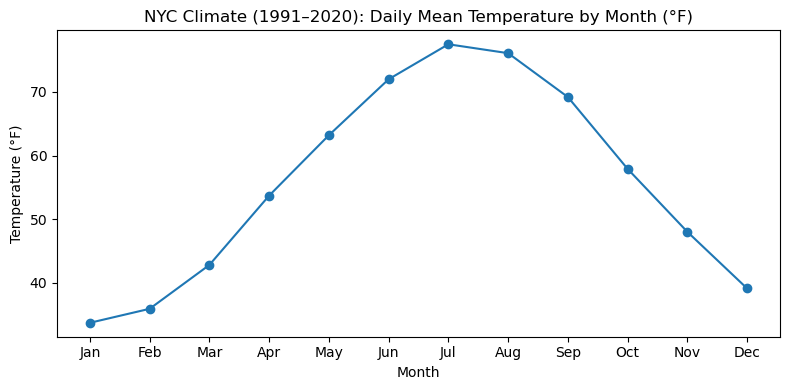

In [6]:
import re

# Remove the "Source" rows (not real data)
climate_num = climate_long[~climate_long["Measure"].str.contains("Source", case=False, na=False)].copy()

# Extract the first number from Value (ex: "60.4 (15.8)" -> 60.4)
def first_number(x):
    m = re.search(r"-?\d+(\.\d+)?", str(x))
    return float(m.group()) if m else np.nan

climate_num["Value_F"] = climate_num["Value"].apply(first_number)

# Keep only the Daily mean row for a clean chart
daily_mean = climate_num[climate_num["Measure"].str.contains("Daily mean", case=False, na=False)].copy()

# Order months correctly
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
daily_mean["Month"] = pd.Categorical(daily_mean["Month"], categories=month_order, ordered=True)
daily_mean = daily_mean.sort_values("Month")

display(daily_mean[["Measure","Month","Value","Value_F"]].head(12))

# Simple line chart
plt.figure(figsize=(8,4))
plt.plot(daily_mean["Month"].astype(str), daily_mean["Value_F"], marker="o")
plt.title("NYC Climate (1991–2020): Daily Mean Temperature by Month (°F)")
plt.xlabel("Month")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Dataset 2 (Wide CSV): Best-selling video games (Wikipedia)
Next I load the wide table from Wikipedia, preview it, and save the wide version as a CSV before tidying.

In [7]:
# Dataset 2 URL
url2 = "https://en.wikipedia.org/wiki/List_of_best-selling_video_games"

# Download HTML (browser-like User-Agent)
req2 = Request(url2, headers={"User-Agent": "Mozilla/5.0"})
html2 = urlopen(req2).read().decode("utf-8")

tables2 = pd.read_html(StringIO(html2))
print("Total tables found:", len(tables2))

# Show the first 10 table column names so we can pick the right one
for i, t in enumerate(tables2[:10]):
    print(i, list(t.columns))

# Also preview table 0 to see what it looks like
display(tables2[0].head())

Total tables found: 4
0 [0]
1 ['Rank', 'Title', 'Sales (millions)', 'Series', 'Platform(s)', 'Release year', 'Developer(s)', 'Publisher(s)', 'Ref.']
2 ['vteBest-selling video game hardware and software', 'vteBest-selling video game hardware and software.1']
3 [0, 1]


,0
0,Video games
1,Platforms Arcade video game Game console Home ...
2,Genres Action Platformer Shooter Action-advent...
3,Lists Arcade games highest-grossing Best-selli...
4,Development Producer Developer Designer Artist...


Saving Dataset 2 (Wide CSV)

I select the main “best-selling video games” table (table index 1) and save it as a wide CSV.

In [8]:
games_wide = tables2[1].copy()

print("Games wide shape:", games_wide.shape)
display(games_wide.head())

out2 = data_dir / "data02_wide.csv"
games_wide.to_csv(out2, index=False)
print("Saved:", out2.resolve())

Games wide shape: (52, 9)


,Rank,Title,Sales (millions),Series,Platform(s),Release year,Developer(s),Publisher(s),Ref.
0,1[a],Tetris,520.0,NaN,Multi-platform,1988[c],Various,Various,[16]
1,1[a],Minecraft,350.0,Minecraft,Multi-platform,2011[d],Mojang Studios,Mojang Studios,[19]
2,2,Grand Theft Auto V,225.0,Grand Theft Auto,Multi-platform,2013,Rockstar North,Rockstar Games,[20]
3,3,Wii Sports [b],82.9,Wii,Wii,2006,Nintendo EAD,Nintendo,[23]
4,4,Red Dead Redemption 2,82.0,Red Dead,Multi-platform,2018,Rockstar Games,Rockstar Games,[20]


Saved: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data02_wide.csv


In [9]:
# Read-back check (required): load the WIDE CSV we just saved
games_wide = pd.read_csv(out2)
display(games_wide.head())

,Rank,Title,Sales (millions),Series,Platform(s),Release year,Developer(s),Publisher(s),Ref.
0,1[a],Tetris,520.0,NaN,Multi-platform,1988[c],Various,Various,[16]
1,1[a],Minecraft,350.0,Minecraft,Multi-platform,2011[d],Mojang Studios,Mojang Studios,[19]
2,2,Grand Theft Auto V,225.0,Grand Theft Auto,Multi-platform,2013,Rockstar North,Rockstar Games,[20]
3,3,Wii Sports [b],82.9,Wii,Wii,2006,Nintendo EAD,Nintendo,[23]
4,4,Red Dead Redemption 2,82.0,Red Dead,Multi-platform,2018,Rockstar Games,Rockstar Games,[20]


Dataset 2 Tidying / Cleaning + Analysis

This dataset is already mostly tidy (each game is a row and each variable is a column), but it still needs cleaning:

Remove citation text like [a], [b] in Rank/Title/Release year

Convert Sales (millions) to numeric
Then I will make a simple chart of the Top 10 best-selling games.

Cleaned games shape: (52, 8)


,Rank,Title,Sales (millions),Series,Platform(s),Release year,Developer(s),Publisher(s)
0,1,Tetris,520.0,NaN,Multi-platform,1988,Various,Various
1,1,Minecraft,350.0,Minecraft,Multi-platform,2011,Mojang Studios,Mojang Studios
2,2,Grand Theft Auto V,225.0,Grand Theft Auto,Multi-platform,2013,Rockstar North,Rockstar Games
3,3,Wii Sports,82.9,Wii,Wii,2006,Nintendo EAD,Nintendo
4,4,Red Dead Redemption 2,82.0,Red Dead,Multi-platform,2018,Rockstar Games,Rockstar Games


Saved tidy: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data02_tidy.csv


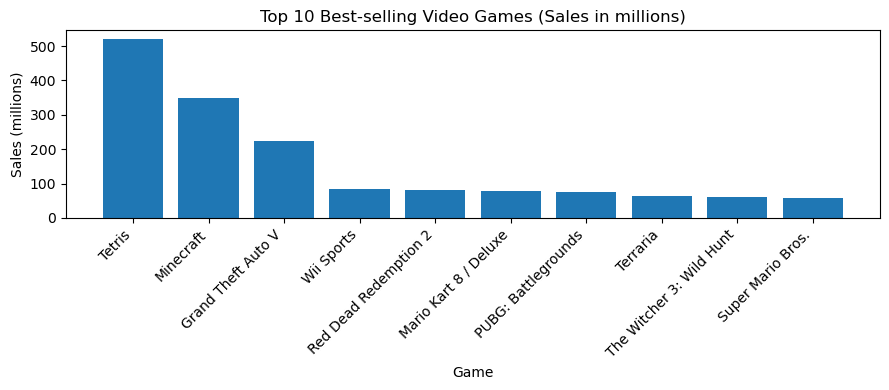

In [10]:
# Copy wide data
games = games_wide.copy()

# Helper: remove citation brackets like [a], [16], etc.
def remove_brackets(x):
    return re.sub(r"\[\w+\]", "", str(x)).strip()

# Clean key text columns
games["Rank"] = games["Rank"].apply(remove_brackets)
games["Title"] = games["Title"].apply(remove_brackets)
games["Release year"] = games["Release year"].apply(remove_brackets)

# Sales should already be numeric, but force it safely
games["Sales (millions)"] = pd.to_numeric(games["Sales (millions)"], errors="coerce")

# Drop Ref. column (not needed for analysis)
if "Ref." in games.columns:
    games = games.drop(columns=["Ref."])

print("Cleaned games shape:", games.shape)
display(games.head())

# Save tidy/clean version
out2_tidy = data_dir / "data02_tidy.csv"
games.to_csv(out2_tidy, index=False)
print("Saved tidy:", out2_tidy.resolve())

# Simple analysis: Top 10 games by sales
top10 = games.sort_values("Sales (millions)", ascending=False).head(10)

plt.figure(figsize=(9,4))
plt.bar(top10["Title"], top10["Sales (millions)"])
plt.title("Top 10 Best-selling Video Games (Sales in millions)")
plt.xlabel("Game")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset 2 (Extra Analysis from discussion post)
In the discussion item, one analysis idea was:

Sales by release year (new vs old)

Which publishers appear most / have the most sales

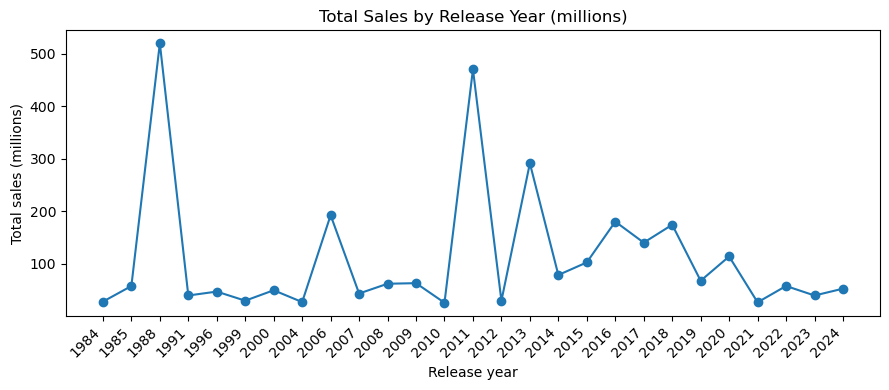

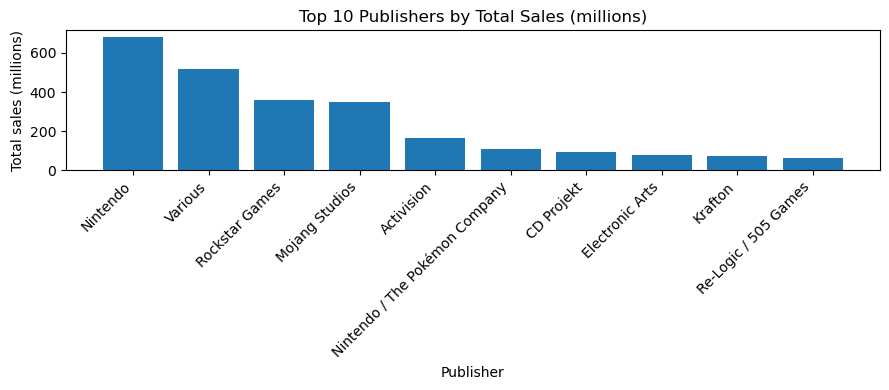

In [11]:
# Sales by release year (sum of sales per year)
games_year = games.dropna(subset=["Release year", "Sales (millions)"]).copy()
games_year["Release year"] = pd.to_numeric(games_year["Release year"], errors="coerce")
games_year = games_year.dropna(subset=["Release year"])
games_year["Release year"] = games_year["Release year"].astype(int)

sales_by_year = games_year.groupby("Release year")["Sales (millions)"].sum().sort_index()

plt.figure(figsize=(9,4))
plt.plot(sales_by_year.index.astype(str), sales_by_year.values, marker="o")
plt.title("Total Sales by Release Year (millions)")
plt.xlabel("Release year")
plt.ylabel("Total sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Publisher analysis (simple)
publisher_sales = games.dropna(subset=["Publisher(s)", "Sales (millions)"]).groupby("Publisher(s)")["Sales (millions)"].sum()
publisher_sales = publisher_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(9,4))
plt.bar(publisher_sales.index, publisher_sales.values)
plt.title("Top 10 Publishers by Total Sales (millions)")
plt.xlabel("Publisher")
plt.ylabel("Total sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset 3 (Wide CSV): NASA JPL Planets table

Next I load the planets table from NASA JPL. I preview the tables and then save the main planets table as a wide CSV before tidying.

In [12]:
# Dataset 3 URL
url3 = "https://ssd.jpl.nasa.gov/planets/"

# Download HTML (browser-like User-Agent)
req3 = Request(url3, headers={"User-Agent": "Mozilla/5.0"})
html3 = urlopen(req3).read().decode("utf-8")

tables3 = pd.read_html(StringIO(html3))
print("Total tables found:", len(tables3))

# Show column names for all tables (usually only a few)
for i, t in enumerate(tables3):
    print(i, list(t.columns), "shape:", t.shape)

# Preview the first table
display(tables3[0].head())

Total tables found: 1
0 ['Page', 'Description'] shape: (5, 2)


,Page,Description
0,Orbits & Ephemerides,Provides access to orbital data for all planets.
1,Physical Parameters,Table of selected physical parameters for the ...
2,Gravity Fields,Visualize and download the gravity fields of s...
3,Observational Data,Provides sets of observations that are current...
4,Discovery Circumstances,Discovery circumstances for the planets.


Dataset 3: Getting the actual planets table

The /planets/ page is a navigation page (links).
The real “planet physical parameters” table is on the Physical Parameters page.
Next I load that page and preview the table(s) so I can save the wide CSV.

In [13]:
# Dataset 3 (Physical Parameters page)
url3 = "https://ssd.jpl.nasa.gov/planets/phys_par.html"

req3 = Request(url3, headers={"User-Agent": "Mozilla/5.0"})
html3 = urlopen(req3).read().decode("utf-8")

tables3 = pd.read_html(StringIO(html3))
print("Total tables found:", len(tables3))

# Show table columns so we pick the right one
for i, t in enumerate(tables3):
    print(i, "shape:", t.shape, "columns:", list(t.columns))

# Preview the first table
display(tables3[0].head())

Total tables found: 3
0 shape: (8, 11) columns: [('Planet', 'Unnamed: 0_level_1'), ('Equatorial Radius', '(km)'), ('Mean Radius', '(km)'), ('Mass', '(×1024 kg)'), ('Bulk Density', '(g cm-3)'), ('Sidereal Rotation Period', '(d)'), ('Sidereal Orbital Period', '(y)'), ('V(1,0)', '(mag)'), ('Geometric Albedo', 'Unnamed: 8_level_1'), ('Equatorial Gravity', '(m s-2)'), ('Escape Velocity', '(km s-1)')]
1 shape: (5, 11) columns: [('Dwarf Planet', 'Unnamed: 0_level_1'), ('Equatorial Radius', '(km)'), ('Mean Radius', '(km)'), ('Mass', '(×1018 kg)'), ('Bulk Density', '(g cm-3)'), ('Sidereal Rotation Period', '(d)'), ('Sidereal Orbital Period', '(y)'), ('V(1,0)', '(mag)'), ('Geometric Albedo', 'Unnamed: 8_level_1'), ('Equatorial Gravity', '(m s-2)'), ('Escape Velocity', '(km s-1)')]
2 shape: (10, 2) columns: [0, 1]


,Planet,Equatorial Radius,Mean Radius,Mass,Bulk Density,Sidereal Rotation Period,Sidereal Orbital Period,"V(1,0)",Geometric Albedo,Equatorial Gravity,Escape Velocity
,Unnamed: 0_level_1,(km),(km),(×1024 kg),(g cm-3),(d),(y),(mag),Unnamed: 8_level_1,(m s-2),(km s-1)
0,Mercury,2440.53 [D] ±0.04,2439.4 [D] ±0.1,0.330103 [F] ±0.000021,5.4289 [*] ±0.0007,58.6462 [C],0.2408467 [B],-0.60 [E] ±0.10,0.106 [B],3.70 [*],4.25 [*]
1,Venus,6051.8 [D] ±1.0,6051.8 [D] ±1.0,4.86731 [G] ±0.00023,5.243 [*] ±0.003,-243.018 [C],0.61519726 [B],-4.47 [E] ±0.07,0.65 [B],8.87 [*],10.36 [*]
2,Earth,6378.1366 [D] ±0.0001,6371.0084 [D] ±0.0001,5.97217 [H] ±0.00028,5.5134 [*] ±0.0003,0.99726968 [B],1.0000174 [B],-3.86 [B],0.367 [B],9.80 [*],11.19 [*]
3,Mars,3396.19 [D] ±0.1,3389.50 [D] ±0.2,0.641691 [I] ±0.000030,3.9340 [*] ±0.0007,1.02595676 [C],1.8808476 [B],-1.52 [B],0.150 [B],3.71 [*],5.03 [*]
4,Jupiter,71492 [D] ±4,69911 [D] ±6,1898.125 [J] ±0.088,1.3262 [*] ±0.0003,0.41354 [C],11.862615 [B],-9.40 [B],0.52 [B],24.79 [*],60.20 [*]


Saving Dataset 3 (Wide CSV)

I select the main planets physical-parameters table (table index 0) and save the wide version as data03_wide.csv.

In [14]:
planets_wide = tables3[0].copy()

print("Planets wide shape:", planets_wide.shape)
display(planets_wide.head())

out3 = data_dir / "data03_wide.csv"
planets_wide.to_csv(out3, index=False)
print("Saved:", out3.resolve())

Planets wide shape: (8, 11)


,Planet,Equatorial Radius,Mean Radius,Mass,Bulk Density,Sidereal Rotation Period,Sidereal Orbital Period,"V(1,0)",Geometric Albedo,Equatorial Gravity,Escape Velocity
,Unnamed: 0_level_1,(km),(km),(×1024 kg),(g cm-3),(d),(y),(mag),Unnamed: 8_level_1,(m s-2),(km s-1)
0,Mercury,2440.53 [D] ±0.04,2439.4 [D] ±0.1,0.330103 [F] ±0.000021,5.4289 [*] ±0.0007,58.6462 [C],0.2408467 [B],-0.60 [E] ±0.10,0.106 [B],3.70 [*],4.25 [*]
1,Venus,6051.8 [D] ±1.0,6051.8 [D] ±1.0,4.86731 [G] ±0.00023,5.243 [*] ±0.003,-243.018 [C],0.61519726 [B],-4.47 [E] ±0.07,0.65 [B],8.87 [*],10.36 [*]
2,Earth,6378.1366 [D] ±0.0001,6371.0084 [D] ±0.0001,5.97217 [H] ±0.00028,5.5134 [*] ±0.0003,0.99726968 [B],1.0000174 [B],-3.86 [B],0.367 [B],9.80 [*],11.19 [*]
3,Mars,3396.19 [D] ±0.1,3389.50 [D] ±0.2,0.641691 [I] ±0.000030,3.9340 [*] ±0.0007,1.02595676 [C],1.8808476 [B],-1.52 [B],0.150 [B],3.71 [*],5.03 [*]
4,Jupiter,71492 [D] ±4,69911 [D] ±6,1898.125 [J] ±0.088,1.3262 [*] ±0.0003,0.41354 [C],11.862615 [B],-9.40 [B],0.52 [B],24.79 [*],60.20 [*]


Saved: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data03_wide.csv


In [15]:
# Read-back check (required): load the WIDE CSV we just saved
planets_wide = pd.read_csv(out3, header=[0, 1])
display(planets_wide.head())

,Planet,Equatorial Radius,Mean Radius,Mass,Bulk Density,Sidereal Rotation Period,Sidereal Orbital Period,"V(1,0)",Geometric Albedo,Equatorial Gravity,Escape Velocity
,Unnamed: 0_level_1,(km),(km),(×1024 kg),(g cm-3),(d),(y),(mag),Unnamed: 8_level_1,(m s-2),(km s-1)
0,Mercury,2440.53 [D] ±0.04,2439.4 [D] ±0.1,0.330103 [F] ±0.000021,5.4289 [*] ±0.0007,58.6462 [C],0.2408467 [B],-0.60 [E] ±0.10,0.106 [B],3.70 [*],4.25 [*]
1,Venus,6051.8 [D] ±1.0,6051.8 [D] ±1.0,4.86731 [G] ±0.00023,5.243 [*] ±0.003,-243.018 [C],0.61519726 [B],-4.47 [E] ±0.07,0.65 [B],8.87 [*],10.36 [*]
2,Earth,6378.1366 [D] ±0.0001,6371.0084 [D] ±0.0001,5.97217 [H] ±0.00028,5.5134 [*] ±0.0003,0.99726968 [B],1.0000174 [B],-3.86 [B],0.367 [B],9.80 [*],11.19 [*]
3,Mars,3396.19 [D] ±0.1,3389.50 [D] ±0.2,0.641691 [I] ±0.000030,3.9340 [*] ±0.0007,1.02595676 [C],1.8808476 [B],-1.52 [B],0.150 [B],3.71 [*],5.03 [*]
4,Jupiter,71492 [D] ±4,69911 [D] ±6,1898.125 [J] ±0.088,1.3262 [*] ±0.0003,0.41354 [C],11.862615 [B],-9.40 [B],0.52 [B],24.79 [*],60.20 [*]


Dataset 3 Cleaning + Analysis

This table includes footnotes (like [D], [*]) and uncertainty text (like ±0.1).
To analyze it, I clean the columns by:

Dropping “Unnamed” columns

Extracting the first numeric value from each cell (so columns become usable as numbers)

Then I make a simple chart comparing Mean Radius (km) for each planet

Cleaned planets shape: (8, 11)


,Planet,Equatorial Radius (km),Mean Radius (km),Mass (×1024 kg),Bulk Density (g cm-3),Sidereal Rotation Period (d),Sidereal Orbital Period (y),"V(1,0) (mag)",Geometric Albedo,Equatorial Gravity (m s-2),Escape Velocity (km s-1)
0,Mercury,2440.5300,2439.4000,0.330103,5.4289,58.646200,0.240847,-0.60,0.106,3.70,4.25
1,Venus,6051.8000,6051.8000,4.867310,5.2430,-243.018000,0.615197,-4.47,0.650,8.87,10.36
2,Earth,6378.1366,6371.0084,5.972170,5.5134,0.997270,1.000017,-3.86,0.367,9.80,11.19
3,Mars,3396.1900,3389.5000,0.641691,3.9340,1.025957,1.880848,-1.52,0.150,3.71,5.03
4,Jupiter,71492.0000,69911.0000,1898.125000,1.3262,0.413540,11.862615,-9.40,0.520,24.79,60.20
5,Saturn,60268.0000,58232.0000,568.317000,0.6871,0.444010,29.447498,-8.88,0.470,10.44,36.09
6,Uranus,25559.0000,25362.0000,86.809900,1.2700,-0.718330,84.016846,-7.19,0.510,8.87,21.38
7,Neptune,24764.0000,24622.0000,102.409200,1.6380,0.671250,164.791320,-6.87,0.410,11.15,23.56


Saved tidy: C:\Users\rezoa\OneDrive\Desktop\IS362_Project2\data\data03_tidy.csv


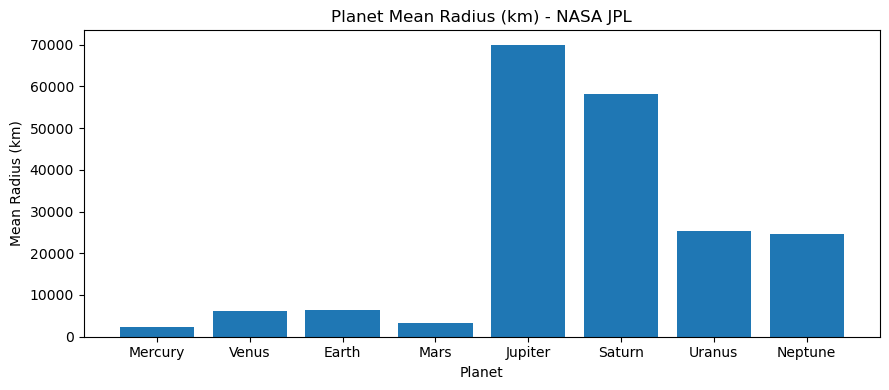

In [16]:
# Start from the wide planets table again
planets = planets_wide.copy()

# 1) Flatten MultiIndex columns the RIGHT way:
# Use the TOP header (variable name), and append the unit if it exists.
if isinstance(planets.columns, pd.MultiIndex):
    new_cols = []
    for top, bottom in planets.columns:
        top = str(top).strip()
        bottom = str(bottom).strip()

        # Keep variable name as the main column name
        name = top

        # Add unit in parentheses (except Planet)
        if name != "Planet" and bottom.startswith("("):
            name = f"{top} {bottom}".strip()

        new_cols.append(name)

    planets.columns = new_cols

# 2) Drop any leftover "Unnamed" columns safely (if any)
mask = ~pd.Index(planets.columns).astype(str).str.startswith("Unnamed")
planets = planets.loc[:, mask].copy()

# 3) Extract the first number from messy strings
import re

def extract_number(x):
    m = re.search(r"-?\d+(\.\d+)?", str(x))
    return float(m.group()) if m else np.nan

# Make numeric columns usable (keep Planet as text)
for c in planets.columns:
    if c != "Planet":
        planets[c] = planets[c].apply(extract_number)

print("Cleaned planets shape:", planets.shape)
display(planets)

# Save tidy/clean version (overwrite with correct one)
out3_tidy = data_dir / "data03_tidy.csv"
planets.to_csv(out3_tidy, index=False)
print("Saved tidy:", out3_tidy.resolve())

# Find the Mean Radius column name (it will be like "Mean Radius (km)")
mean_radius_col = [c for c in planets.columns if "Mean Radius" in c][0]

# Simple chart: Mean Radius by planet
plt.figure(figsize=(9,4))
plt.bar(planets["Planet"], planets[mean_radius_col])
plt.title("Planet Mean Radius (km) - NASA JPL")
plt.xlabel("Planet")
plt.ylabel(mean_radius_col)
plt.tight_layout()
plt.show()

Dataset 3 (Extra Analysis from discussion post)
In the discussion item, one analysis idea was comparing planet mass and gravity.
Here I check the correlation and make a scatter plot.

Correlation (Mass vs Equatorial Gravity): 0.918


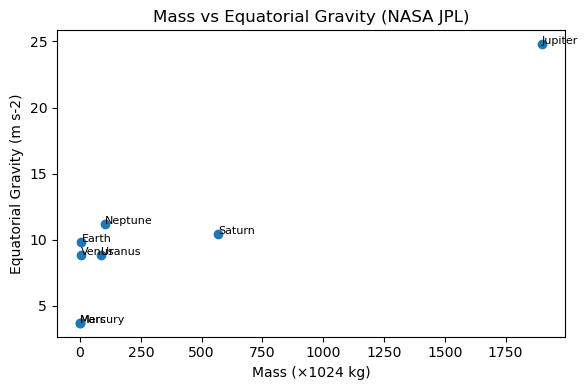

In [17]:
# Find the correct column names (they include units)
mass_col = [c for c in planets.columns if "Mass" in c][0]
grav_col = [c for c in planets.columns if "Equatorial Gravity" in c][0]

corr = planets[mass_col].corr(planets[grav_col])
print("Correlation (Mass vs Equatorial Gravity):", round(corr, 3))

plt.figure(figsize=(6,4))
plt.scatter(planets[mass_col], planets[grav_col])

# Label points
for _, row in planets.iterrows():
    plt.text(row[mass_col], row[grav_col], row["Planet"], fontsize=8)

plt.title("Mass vs Equatorial Gravity (NASA JPL)")
plt.xlabel(mass_col)
plt.ylabel(grav_col)
plt.tight_layout()
plt.show()

Dataset 1: Daily mean temperature peaks in summer and is lowest in winter.

Dataset 2: A small number of titles dominate total sales.

Dataset 3: Jupiter and Saturn have much larger radii than the inner planets.